In [30]:
#########################################
####                                 ####
####             IMPORTS             ####
####                                 ####
#########################################

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import string
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [31]:
########################################
####                                ####
####         FILES CHECKING         ####
####                                ####
########################################

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/sample_submission.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---- Analysis for Training Dataset ----


       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB



/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


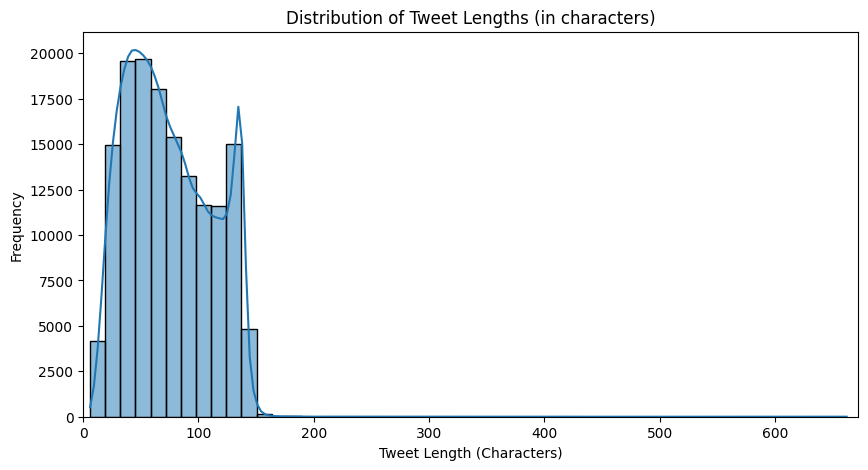

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


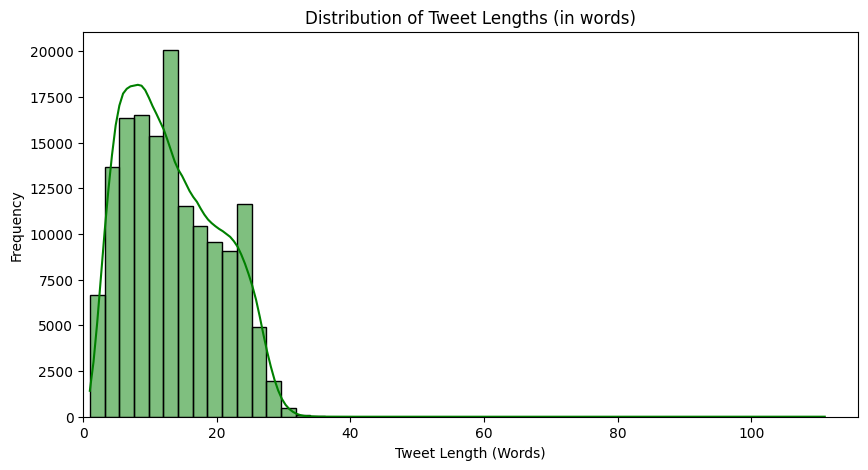

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


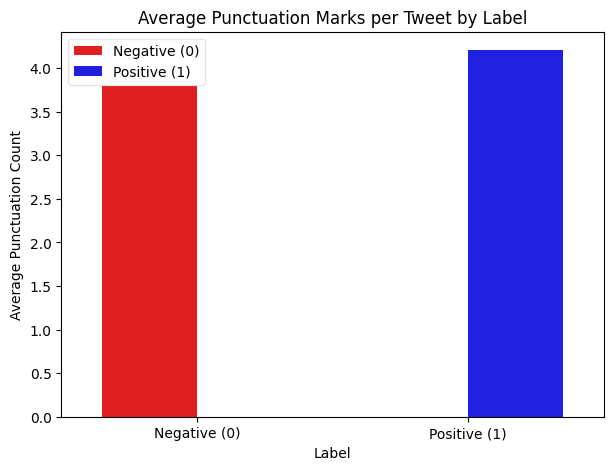

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


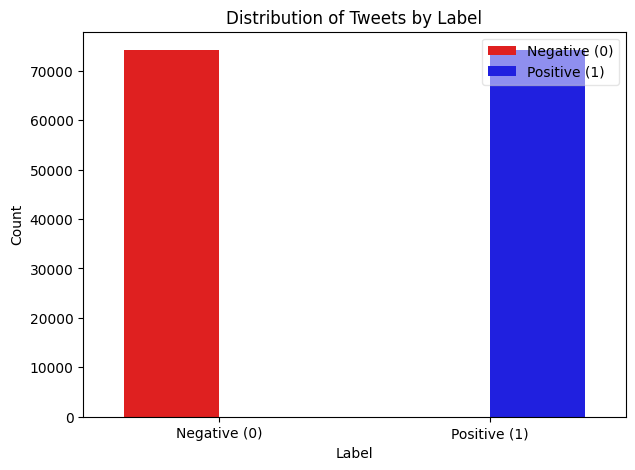

Positive tweets in dataset: 74196
Negative tweets in dataset: 74192



/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


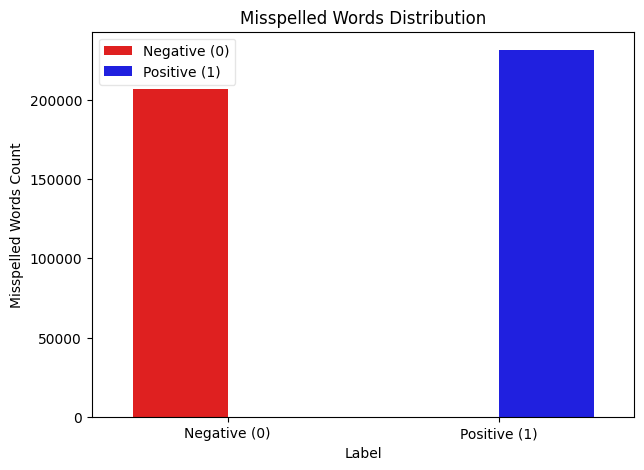

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


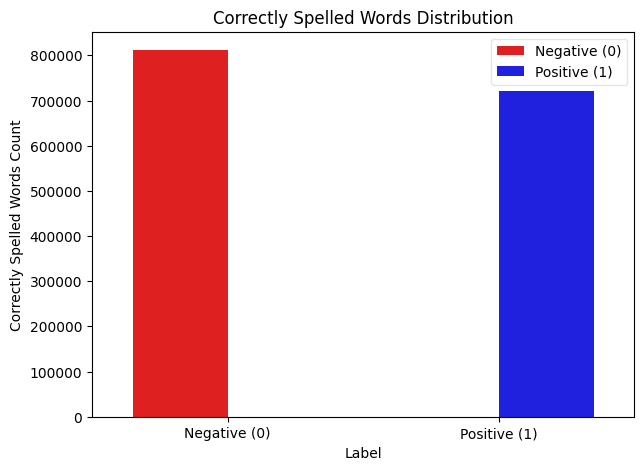



---- Analysis for Validation Dataset ----


       ID                                               Text  Label
0  187062  @NatexTheGreat heyheyhey maybe i will  get the...      0
1  168997  @molliesmummy Work? Work was crap. I missed yo...      0
2  194461  Want: Trip to Boston next month. Need: Addit'l...      1
3  165442                        first day starts tomorrow!       1
4   34853  @goodforyoursoul 8 course fish in Little Saigo...      1

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB



/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


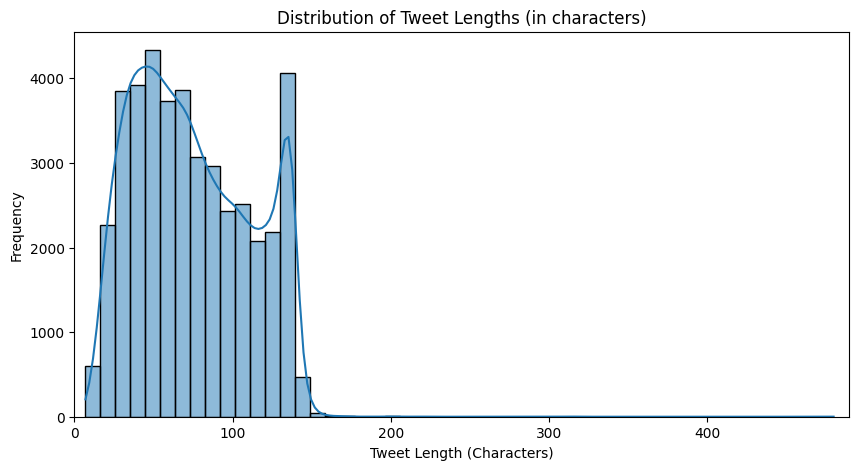

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


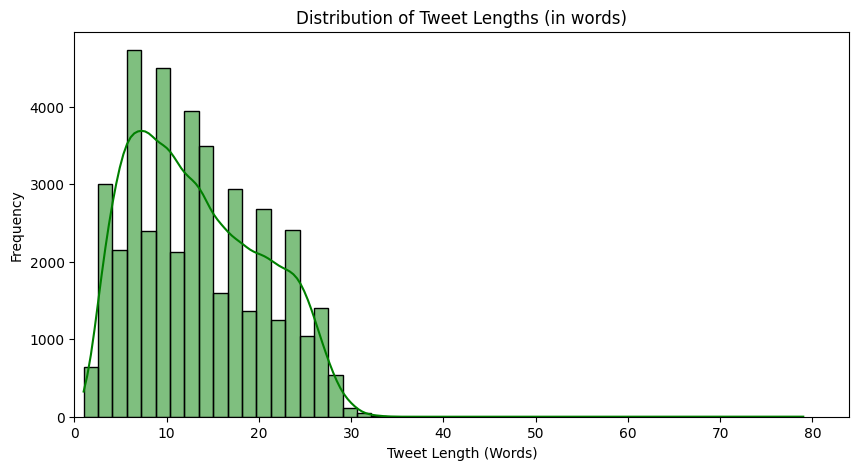

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


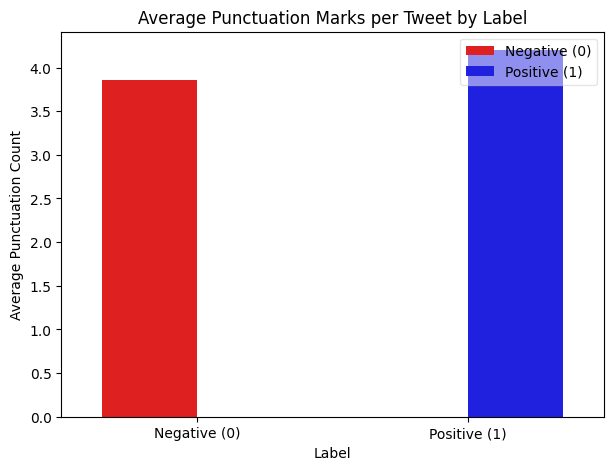

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


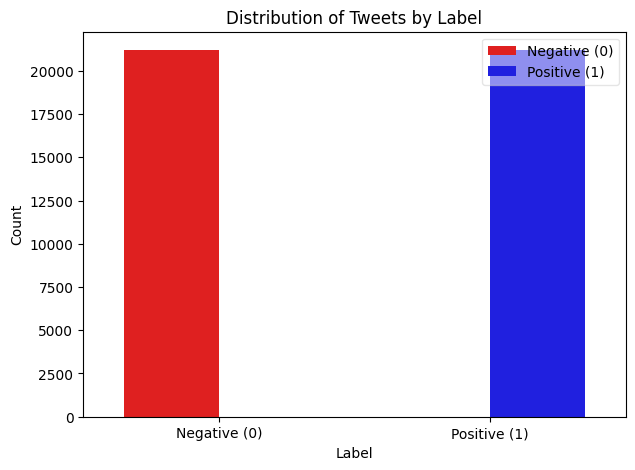

Positive tweets in dataset: 21199
Negative tweets in dataset: 21197



/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


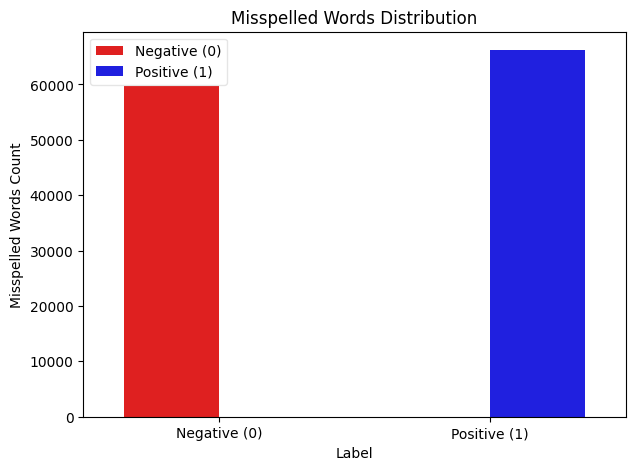

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


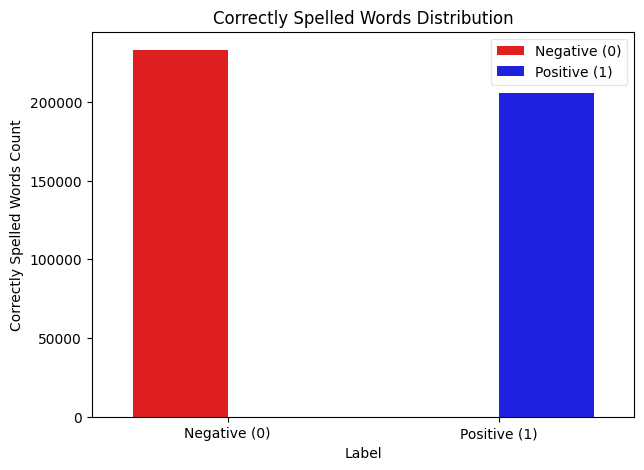

In [ ]:
#########################################
####                                 ####
####               EDA               ####
####                                 ####
#########################################

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import string
from nltk.corpus import stopwords
from collections import Counter
import nltk
from spellchecker import SpellChecker

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
spell = SpellChecker()

def count_misspelled_words(text):
    words = text.split()
    misspelled = spell.unknown(words)
    return len(misspelled)

def count_correctly_spelled_words(text):
    words = text.split()
    misspelled = spell.unknown(words)
    return len(words) - len(misspelled)

def perform_eda(df, dataset_name):
    print(f'\n\n---- Analysis for {dataset_name} ----\n\n')
    print(df.head())
    print('')
    
    # basic info
    print('Basic info:')
    df.info()
    print('')
    
    # features fetching/extracting/calculating
    df['tweet_length'] = df['Text'].apply(len)
    df['word_count'] = df['Text'].apply(lambda x: len(x.split()))
    df['punctuation_count'] = df['Text'].apply(lambda x: sum(1 for char in x if char in string.punctuation))
    df['misspelled_count'] = df['Text'].apply(count_misspelled_words)
    df['correctly_spelled_count'] = df['Text'].apply(count_correctly_spelled_words)
    
    # distribution of tweet lengths (characters)
    plt.figure(figsize=(10,5))
    sns.histplot(df['tweet_length'], bins=50, kde=True)
    plt.xlabel('Tweet Length (Characters)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Tweet Lengths (in characters)')
    plt.xlim(0, df['tweet_length'].max()+10)
    plt.show()
    
    # distribution of tweet lengths (words)
    plt.figure(figsize=(10,5))
    sns.histplot(df['word_count'], bins=50, kde=True, color='green')
    plt.xlabel('Tweet Length (Words)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Tweet Lengths (in words)')
    plt.xlim(0, df['word_count'].max()+5)
    plt.show()
    
    # average punctuation marks per tweet by label
    avg_punct = df.groupby('Label')['punctuation_count'].mean()
    plt.figure(figsize=(7,5))
    sns.barplot(x=['Negative (0)', 'Positive (1)'],
                y=avg_punct.values,
                hue=['Negative (0)', 'Positive (1)'],
                palette={'Negative (0)': 'red', 'Positive (1)': 'blue'},
                width=0.7)
    plt.legend(framealpha=0.5)
    plt.xlabel('Label')
    plt.ylabel('Average Punctuation Count')
    plt.title('Average Punctuation Marks per Tweet by Label')
    plt.show()
    
    # distribution of tweets by label
    num_negative = (df['Label'] == 0).sum()
    num_positive = (df['Label'] == 1).sum()
    plt.figure(figsize=(7,5))
    sns.barplot(x=['Negative (0)', 'Positive (1)'],
                y=[num_negative, num_positive],
                hue=['Negative (0)', 'Positive (1)'],
                palette={'Negative (0)': 'red', 'Positive (1)': 'blue'},
                width=0.7)
    plt.legend(framealpha=0.5)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.title('Distribution of Tweets by Label')
    plt.show()
    # printing exact count in each case
    print(f"Positive tweets in dataset: {num_positive}")
    print(f"Negative tweets in dataset: {num_negative}")
    print("")
    
    # misspelled words per label
    misspelled_counts = df.groupby('Label')['misspelled_count'].sum()
    plt.figure(figsize=(7,5))
    sns.barplot(x=['Negative (0)', 'Positive (1)'],
                y=misspelled_counts.values,
                hue=['Negative (0)', 'Positive (1)'],
                palette={'Negative (0)': 'red', 'Positive (1)': 'blue'},
                width=0.7)
    plt.legend(framealpha=0.5)
    plt.xlabel('Label')
    plt.ylabel('Misspelled Words Count')
    plt.title('Misspelled Words Distribution')
    plt.show()
    
    # correctly spelled words per label
    correctly_spelled_counts = df.groupby('Label')['correctly_spelled_count'].sum()
    plt.figure(figsize=(7,5))
    sns.barplot(x=['Negative (0)', 'Positive (1)'],
                y=correctly_spelled_counts.values,
                hue=['Negative (0)', 'Positive (1)'],
                palette={'Negative (0)': 'red', 'Positive (1)': 'blue'},
                width=0.7)
    plt.legend(framealpha=0.5)
    plt.xlabel('Label')
    plt.ylabel('Correctly Spelled Words Count')
    plt.title('Correctly Spelled Words Distribution')
    plt.show()
    
train_df = pd.read_csv("train_dataset.csv")
val_df = pd.read_csv("val_dataset.csv")

perform_eda(train_df, "Training Dataset")
perform_eda(val_df, "Validation Dataset")

In [ ]:
##########################################
####                                  ####
####          PRE-PROCESSING          ####
####                                  ####
##########################################

import re
import nltk
import html
import contractions
from spellchecker import SpellChecker
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize

test_df = pd.read_csv("test_dataset.csv")

# initialize spell checker
spell = SpellChecker(distance=1)

def remove_contractions(text):
    # expand contractions (e.g haven't -> have not)
    return contractions.fix(text)

def my_spellcheck(text):
    words = text.split()
    corrected_words = []
    for word in words:
        # if it's wrong
        if word not in spell:
            test_word = spell.correction(word)
            # found correction
            if test_word is not None:
                corrected_words.append(test_word)
            # didn't find correction
            else:
                corrected_words.append(word)
        # else, if it's correct, append it to the corrected
        else:
            corrected_words.append(word)
    return " ".join(corrected_words)

def text_cleanup(text):
    text = text.lower() # lowercase everything
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', 'email', text) # handle email adresses
    text = re.sub(r'http[s]?://\S+', 'url', text) # handle urls
    text = re.sub(r'@\w+', '', text) # remove mentions (@username)
    text = re.sub(r'#(\w+)', r'\1', text) # handle hashtags: remove the symbol, keep the text
    text = re.sub(r'\.{2,}', ' ', text) # removing ellipses (..., ...., ....., etc)
    text = html.unescape(text) # handling html tags
    text = re.sub(r'(\w)\1{2,}', r'\1\1', text) # handling unecessarily long words (e.g. soooooo -> so)
    text = remove_contractions(text) # handling contractions (haven't -> have not)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # remove anything that is not english, a number or a whitespace
    text = my_spellcheck(text) # spellchecking using pyspellchecker
    return text

# apply cleanup to both datasets
train_df["Text"] = train_df["Text"].apply(text_cleanup)
val_df["Text"] = val_df["Text"].apply(text_cleanup)
test_df["Text"] = test_df["Text"].apply(text_cleanup)

In [34]:
#################################################
####                                         ####
####      MODEL TRAINING AND EVALUATION      ####
####                                         ####
#################################################

# splitting features (Text) and target (Label)
X_train = train_df["Text"]
y_train = train_df["Label"]
X_val = val_df["Text"]
y_val = val_df["Label"]

# TF-IDF vectorization
vectorizer = TfidfVectorizer(ngram_range=(1,4), max_features=100000, min_df=3, max_df=0.9)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# train logistic regression model
model = LogisticRegression(random_state=161)
model.fit(X_train_tfidf, y_train)

# prediction
y_pred = model.predict(X_val_tfidf)

# evaluation
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.20f}")
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.80590150014152273084
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80     21197
           1       0.80      0.81      0.81     21199

    accuracy                           0.81     42396
   macro avg       0.81      0.81      0.81     42396
weighted avg       0.81      0.81      0.81     42396



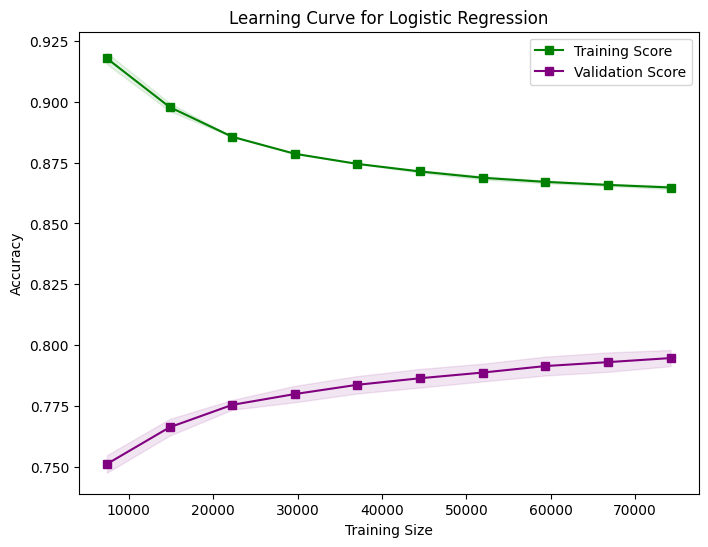

In [35]:
#########################################
####                                 ####
####         LEARNING CURVES         ####
####                                 ####
#########################################

# generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=200), X_train_tfidf, y_train, cv=2, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10)
)

# compute mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="green", marker="s")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="green")

plt.plot(train_sizes, test_mean, label="Validation Score", color="purple", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="purple")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

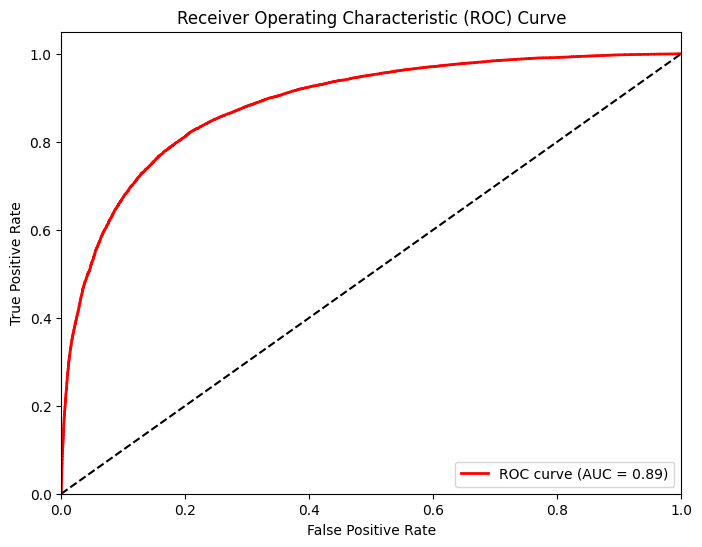

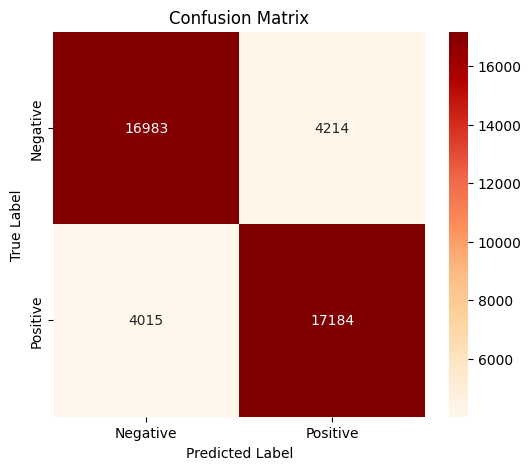

In [36]:
##############################################
####                                      ####
####        ROC & CONFUSION MATRIX        ####
####                                      ####
##############################################

from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

# ROC
y_val_prob = model.predict_proba(X_val_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)
# plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="OrRd", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

In [37]:
#####################################
####                             ####
####      KAGGLE SUBMISSION      ####
####                             ####
#####################################

X_test_tfidf = vectorizer.transform(test_df["Text"])

test_predictions = model.predict(X_test_tfidf)

submission_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": test_predictions
})

submission_df.to_csv("submission.csv", index=False)
print("Created submission csv file")

Created submission csv file
